In [24]:
import arviz as az
import pandas as pd
from sklearn.metrics import roc_auc_score, brier_score_loss
import pymc as pm
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import japanize_matplotlib

In [9]:
df_sub_cross = pd.read_csv("../data/df_sub_cross_random_effect.csv", index_col=0)
df_sub_logi = pd.read_csv("../data/df_sub_logistic.csv", index_col=0)
converted_cross = df_sub_cross["converted"].values
converted_logi = df_sub_logi["converted"].values

=== Model Comparison (LOO) ===


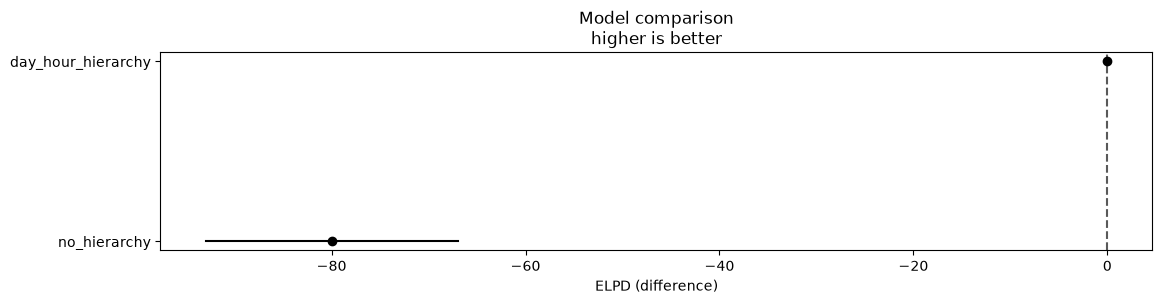

In [6]:
#WAIC/LOOによるモデル比較→予測分布全体のあてはまり
trace_nuts = az.from_netcdf("../models/trace_nuts.nc")
trace_hier = az.from_netcdf("../models/trace_hier.nc")

comparison = az.compare({
    "no_hierarchy": trace_nuts,
    "day_hour_hierarchy": trace_hier
})

print("=== Model Comparison (LOO) ===")
az.plot_compare(comparison)

In [7]:
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
day_hour_hierarchy,0,0.0,0.0,NaN,,,26.1,-8500.0,140.0,0.98
no_hierarchy,1,-80.0,13.0,1.0,,,3.3,-8600.0,140.0,0.02


In [14]:
#順位付けの精度（AUC-ROC）と確率の絶対的な当てはまり（Brier）
p_mean_hier = trace_hier.posterior["p"].mean(dim=["chain", "draw"]).values
p_mean_logi = trace_nuts.posterior["p"].mean(dim=["chain", "draw"]).values

auc_hier = roc_auc_score(converted_cross, p_mean_hier)
brier_hier = brier_score_loss(converted_cross, p_mean_hier)
auc_logi = roc_auc_score(converted_logi, p_mean_logi)
brier_logi = brier_score_loss(converted_logi, p_mean_logi)

print(f"AUC-ROC(階層構造): {auc_hier:.4f}") 
print(f"Brier score(階層構造): {brier_hier:.4f}")
print(f"AUC-ROC(ロジスティック): {auc_logi:.4f}") 
print(f"Brier score(ロジスティック): {brier_logi:.4f}")



AUC-ROC(階層構造): 0.8565
Brier score(階層構造): 0.0236
AUC-ROC(ロジスティック): 0.8527
Brier score(ロジスティック): 0.0238


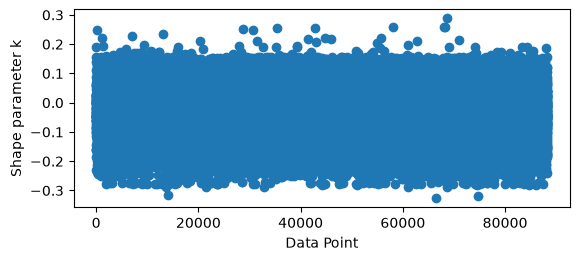

In [16]:
#Pareto-k診断（LOO計算の近似がどれだけ信頼できるか）
loo_result = az.loo(trace_hier, pointwise=True)

az.plot_khat(loo_result)

In [17]:
loo_result

Computed from 4000 posterior samples and 88215 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -8549.15   141.26
p_loo       26.11        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     88215  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%

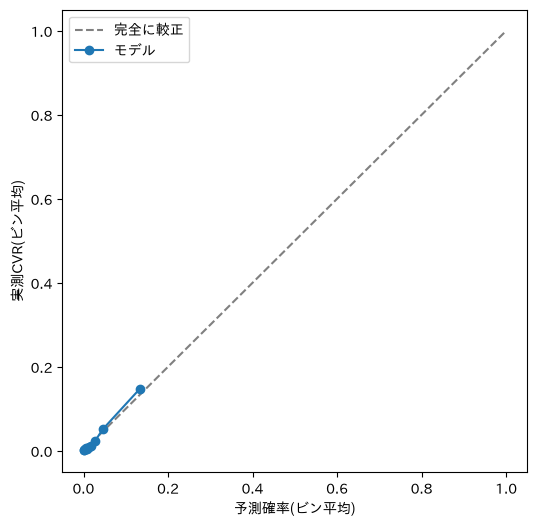

In [25]:
prob_true, prob_pred = calibration_curve(converted_cross, p_mean_hier, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="完全に較正")
ax.plot(prob_pred, prob_true, marker="o", label="モデル")
ax.set_xlabel("予測確率(ビン平均)")
ax.set_ylabel("実測CVR(ビン平均)")
ax.legend()
plt.show()